<a href="https://colab.research.google.com/github/eliastche/PythonLabs/blob/main/Python_for_finance_Exam_CF_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before you start
* Deactivate any generative AI assistance tool:
  * Go to Tools
  * Go to Settings
  * Go to AI Assistance
  * Tick the box "Hide generative AI features"

You will be penalized if you start the test with generative AI features enabled. Let me know if you need help.


# Exam duration : 2h30

# Part 1 : programming exercises (6 points)

### Exercise 1 (1 point)
* Write a function that checks if a temperature value given as parameter is cold (below 15), moderate (between 15 and 30) or hot (above 30). The function should print the result.

In [14]:
def tempcheck(temp):
  temperature = ""
  if temp < 15:
    temperature = "Cold"
  elif temp > 30:
    temperature = "Hot"
  else:
    temperature = "Moderate"

  return print("A temperature of", temp, "is", temperature)

tempcheck(15)

A temperature of 15 is Moderate


### Exercise 2 (2.5 points)
* Write a function that takes a number as parameter and prints its multiplication table (from 1 to 10).

In [16]:
def multable(a):
  list1 = []
  for i in range(10):
    list1.append((i + 1) * a)

  return print(list1)

multable(4)



[4, 8, 12, 16, 20, 24, 28, 32, 36, 40]


### Exercise 3 (2.5 points)

* Write a function that takes an integer as input and calculates the product of its digits using a while loop. For example, if the input is 234, the output should be 2 * 3 * 4 = 24.

In [32]:
def digprod(a):
  digits = []

  while a > 0:
    digits.insert(0, a % 10)  # get the last digit
    a = a //10

  digitprod = 1
  for i in digits:
    digitprod =i*digitprod


  return print(digitprod)

digprod(236)

36


# Part 2 : Data analysis and manipulation (10 points)


### 1. Load some stocks information into a pandas DataFrame (1 point)
* Using the yfinance module, download the Apple stocks (ticker 'AAPL') in a DataFrame

In [33]:
import yfinance as yf

stock = yf.download("AAPL")
aapl_stock = stock.xs("AAPL", axis = 1, level = 1)

aapl_stock.head()

/tmp/ipython-input-3329304997.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-10-15,249.098526,251.576135,247.230342,249.248390,33893600
2025-10-16,247.210358,248.798814,244.892612,248.009586,39777000
2025-10-17,252.045654,253.134610,247.030527,247.779801,49147000
2025-10-20,261.986023,264.123965,255.382439,255.642182,90483000
2025-10-21,262.515503,265.033082,261.576411,261.626381,46695900


### 2. Data analysis (4 points)
First two questions : justify your answers by writing down and executing the code that helped you answer the question.

* a. What is the first date in that DataFrame ? (1 point)
* b. What is the last date in that DataFrame ? (1 point)
* c. Plot the High column as a function of time using seaborn (1 points)
* d. Plot a histogram of the Close column
(1 points)


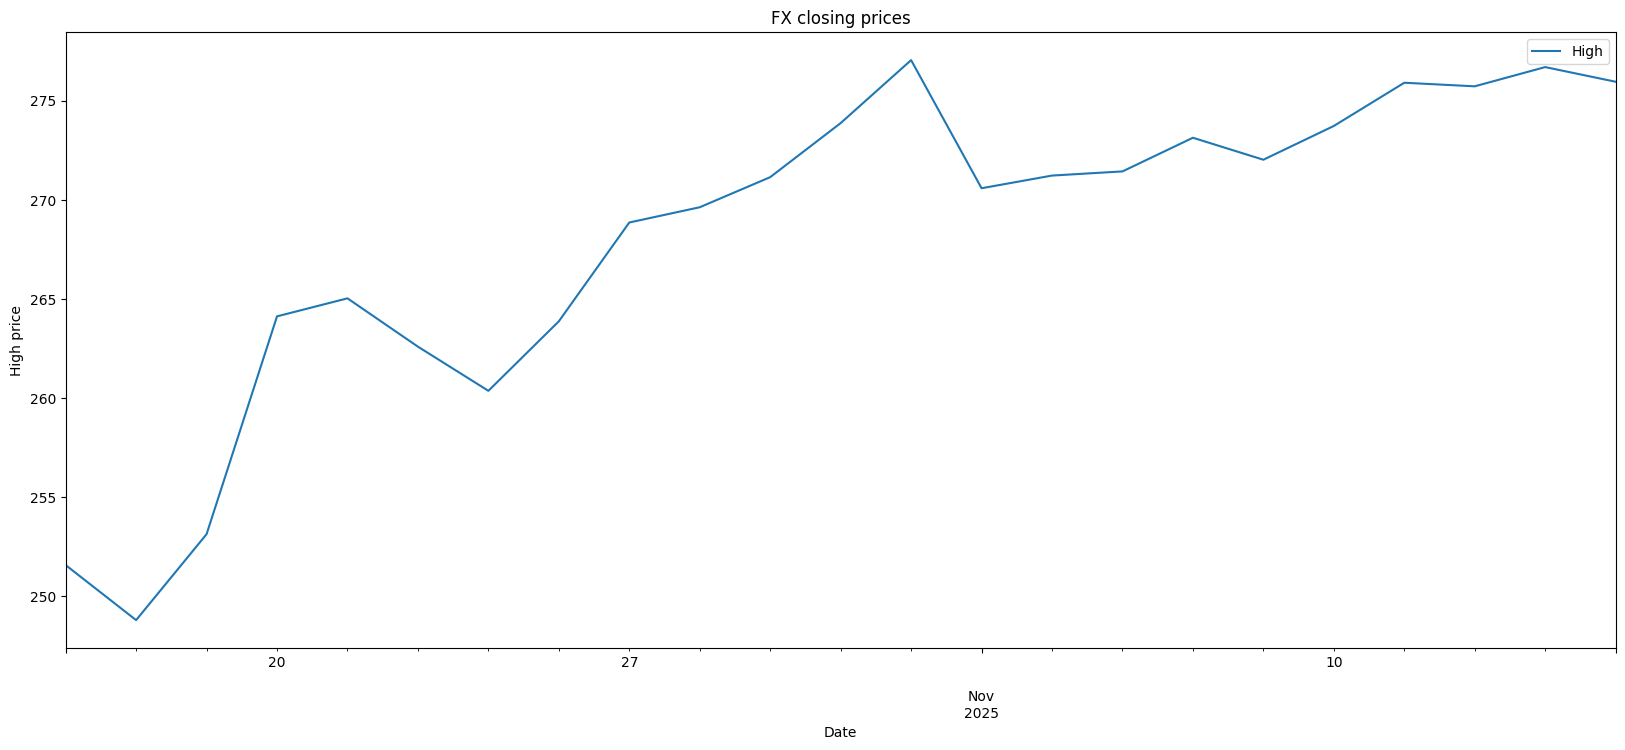

In [37]:
aapl_stock.head(1)
aapl_stock.tail(1)


#Question c
import matplotlib.pyplot as plt
import seaborn as sns

aapl_stock.plot(y = 'High', use_index=True, figsize=(20,8))

plt.title("FX closing prices")

plt.xlabel("Date")
plt.ylabel("High price")
sns.set_style("darkgrid")

plt.show()

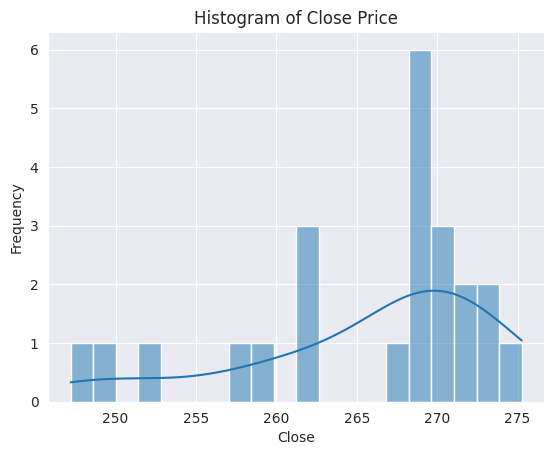

In [40]:
#Question d Plot a histogram of the Volume column
sns.histplot(aapl_stock["Close"].dropna(), bins=20, kde=True)
plt.title("Histogram of Close Price")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()

### 3. Data manipulation (5 points)
* **a. Daily return.** Add a column 'Daily Return' to the DataFrame. That column should contain the daily return value (i.e. the change in percentage from one day to the next). Compute these values by calculating a percentage change on the Close column. (1 point)
* **b. Cumulative returns.** Add a column 'Cumulative return' to the DataFrame. Values in that column should be the cumulative returns, which capture the compounded effect of daily returns: it can be computed by applying a cumulative product function (cumprod) to the daily return + 1, and then substracting 1 in the end. In other words : Cumulative Return=(∏(1+Daily Returns))−1 (2 points)
* **c. Volume weighted average price.** Add a column 'VWAP' to the DataFrame. This column should contain the volume weighted average price. This can be computed by computing the cumulative sum (with the function cumsum()) of the product between closing values and volumes, divided by the cumulative sum of volumes.  (2 points)

In [46]:
from numpy._core.fromnumeric import cumsum
from numpy import cumprod
aapl_stock["Daily Return"] = aapl_stock["Close"].pct_change()

aapl_stock["Cumulative Return"] = cumprod(1+aapl_stock["Daily Return"])-1

aapl_stock["VWAP"] = cumsum(aapl_stock["Close"]*aapl_stock["Volume"])/cumsum(aapl_stock["Volume"])

aapl_stock.head()



Price,Close,High,Low,Open,Volume,Daily Return,Cumulative Return,VWAP
Date,,,,,,,,
2025-10-15,249.098526,251.576135,247.230342,249.248390,33893600,NaN,NaN,249.098526
2025-10-16,247.210358,248.798814,244.892612,248.009586,39777000,-0.007580,-0.007580,248.079046
2025-10-17,252.045654,253.134610,247.030527,247.779801,49147000,0.019559,0.011831,249.666334
2025-10-20,261.986023,264.123965,255.382439,255.642182,90483000,0.039439,0.051737,254.892397
2025-10-21,262.515503,265.033082,261.576411,261.626381,46695900,0.002021,0.053862,256.261523
